In [1]:
#Inicio importando las librerias que necesito
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt 

In [2]:
#Carga del dataset de Sabadell en Python
df_datasabadell = pd.read_csv(r'C:\Users\jmendozarojas\OneDrive - Getronics\Escritorio\INESDI\TFM\MUESTRA_UB.csv', sep=';', header='infer', encoding='latin-1', engine='python')


In [3]:
#Realizamos la confirmación de la carga
df_datasabadell.head()

,id_cliente,antig,edad,totalpasta,impoped,impopeh,ind_cuentaexpansion,ind_cuentaexpansionnegocios,ind_cuentaexpansionpremium,ind_cuentaexperiencia,...,prov,credit,revolving,tothipo,nominaimp,rdom,tpv,margecomercialut,total_proteccio,fase
0,1,194,84,52043.01,5516.79,23100.89,1,0,0,0,...,28,0.0,0.0,0.0,0.00,38,0,105.19,0,29.0
1,2,244,75,4219.46,744.74,0.00,0,0,0,0,...,8,0.0,0.0,0.0,0.00,4,0,32.42,0,30.0
2,3,336,84,55585.45,1152.96,400.20,0,0,0,0,...,8,0.0,0.0,0.0,0.00,4,0,123.41,0,30.0
3,4,278,55,5813.22,11449.97,15317.10,0,0,0,0,...,28,0.0,0.0,0.0,12645.48,41,0,22.51,0,16.0
4,5,36,55,19000.00,0.00,0.00,0,0,0,0,...,28,0.0,0.0,0.0,0.00,0,0,28.26,0,27.0


In [5]:
#funcion para identificar los campos nulos de la tabla
print("Nulos por columna:")
print(df_datasabadell.isnull().sum())

Nulos por columna:
id_cliente            0
antig                 0
edad                  0
totalpasta            0
impoped               0
                   ... 
rdom                  0
tpv                   0
margecomercialut      0
total_proteccio       0
fase                114
Length: 84, dtype: int64


In [6]:
#Consultamos la tabla
df_datasabadell.head()

,id_cliente,antig,edad,totalpasta,impoped,impopeh,ind_cuentaexpansion,ind_cuentaexpansionnegocios,ind_cuentaexpansionpremium,ind_cuentaexperiencia,...,prov,credit,revolving,tothipo,nominaimp,rdom,tpv,margecomercialut,total_proteccio,fase
0,1,194,84,52043.01,5516.79,23100.89,1,0,0,0,...,28,0.0,0.0,0.0,0.00,38,0,105.19,0,29.0
1,2,244,75,4219.46,744.74,0.00,0,0,0,0,...,8,0.0,0.0,0.0,0.00,4,0,32.42,0,30.0
2,3,336,84,55585.45,1152.96,400.20,0,0,0,0,...,8,0.0,0.0,0.0,0.00,4,0,123.41,0,30.0
3,4,278,55,5813.22,11449.97,15317.10,0,0,0,0,...,28,0.0,0.0,0.0,12645.48,41,0,22.51,0,16.0
4,5,36,55,19000.00,0.00,0.00,0,0,0,0,...,28,0.0,0.0,0.0,0.00,0,0,28.26,0,27.0


In [7]:
#Función para contar la cantidad total de clientes en la BD
total_clientes=df_datasabadell.id_cliente.count()
print(f"El total de clientes registrados en la BD es : {total_clientes}")


El total de clientes registrados en la BD es : 10000


In [8]:
#Analisis de los datos atipicos, conteno e identificación 
cantidad_9999 = (df_datasabadell['antig'] == 9999).sum()
print(f"Cantidad de registros con antig == '9999, posibles datos atipicos': {cantidad_9999}")



Cantidad de registros con antig == '9999, posibles datos atipicos': 64


In [14]:
#Opción #1: Transformación de los valores Anómalos, realizar la transformación a un valor consistente seleccionamos 600 meses que equivale a 50 años de antiguedad  
df_datasabadell['antig'] = df_datasabadell['antig'].replace(9999, 600)

In [15]:
#Opción 2: Eliminar los 64 registros con esos valores antig=9999
df_delete = df_datasabadell[df_datasabadell['antig'] == 9999].copy()
print(f"CORRECCIÓN: Registros con antig == 9999 (para eliminar): {len(df_delete)}")


CORRECCIÓN: Registros con antig == 9999 (para eliminar): 0


In [16]:
df_delete.head()

,id_cliente,antig,edad,totalpasta,impoped,impopeh,ind_cuentaexpansion,ind_cuentaexpansionnegocios,ind_cuentaexpansionpremium,ind_cuentaexperiencia,...,prov,credit,revolving,tothipo,nominaimp,rdom,tpv,margecomercialut,total_proteccio,fase


In [17]:
# Para eliminar realmente del DataFrame principal
df_datasabadell = df_datasabadell[df_datasabadell['antig'] != 9999]

print("\nEliminados los registros con valores 9999")


Eliminados los registros con valores 9999


In [12]:

#Segementacion de clientes por tipo de cuenta 
# Lista de columnas a seleccionar
columnas_seleccion = [
    'id_cliente',
    'ind_cuentaexpansion',
    'ind_cuentaexpansionnegocios',
    'ind_cuentaexpansionpremium',
    'ind_cuentaexperiencia',
    'ind_cuentaprimera',
    'ind_cuentaproyeccion',
    'ind_cvautonomos',
    'ind_cvdirect',
    'ind_cvhabit',
    'ind_cvjove',
    'ind_cvjunior',
    'ind_cvmas',
    'ind_cvprestige',
    'ind_cvsenior',
    'ind_estalinv',
    'ind_estalvi',
    'ind_estrangers'
]

# Seleccionar las columnas (syntax correcta)
df_tipocuenta = df_datasabadell[columnas_seleccion].copy()



In [10]:
df_tipocuenta.head()

,id_cliente,ind_cuentaexpansion,ind_cuentaexpansionnegocios,ind_cuentaexpansionpremium,ind_cuentaexperiencia,ind_cuentaprimera,ind_cuentaproyeccion,ind_cvautonomos,ind_cvdirect,ind_cvhabit,ind_cvjove,ind_cvjunior,ind_cvmas,ind_cvprestige,ind_cvsenior,ind_estalinv,ind_estalvi,ind_estrangers
0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0


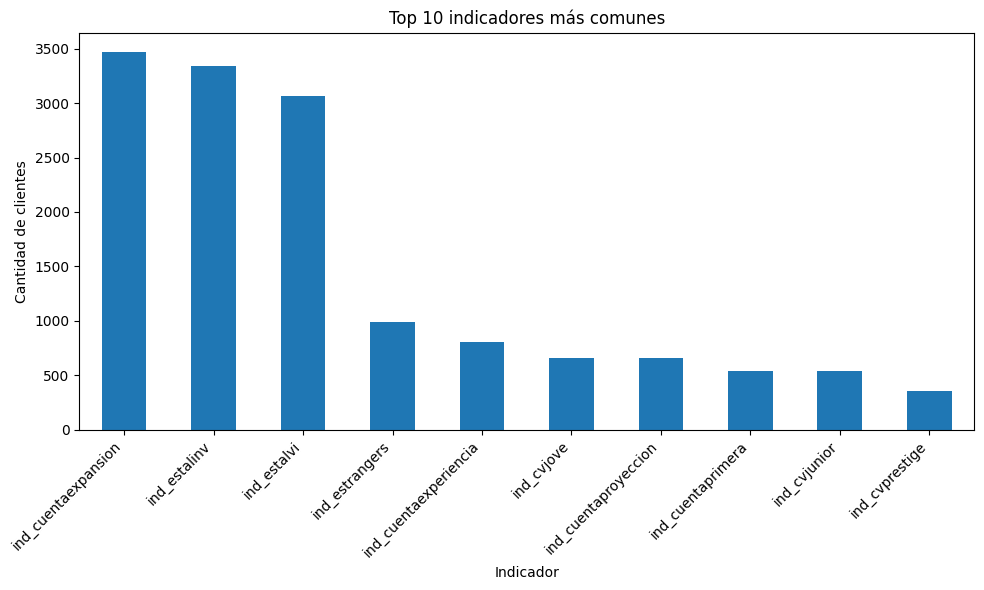

In [11]:
# Contar cuántos clientes tienen cada indicador activo
conteo_indicadores = {}
for col in columnas_seleccion:
    if col != 'id_cliente' and col in df_tipocuenta.columns:
        # Asumiendo que los indicadores son binarios (0/1 o True/False)
        conteo = df_tipocuenta[col].sum() if df_tipocuenta[col].dtype in [int, float, bool] else len(df_tipocuenta[df_tipocuenta[col] == True])
        conteo_indicadores[col] = conteo

# Crear gráfico
pd.Series(conteo_indicadores).sort_values(ascending=False).head(10).plot(
    kind='bar',
    title='Top 10 indicadores más comunes',
    figsize=(10, 6)
)
plt.xlabel('Indicador')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
